In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('imagen.csv')

In [4]:
df

,tamanio,procesamiento,precision
0,Pequena,Ninguno,0.85
1,Pequena,Binarizacion,0.85
2,Pequena,Ecualizacion,0.93
3,Mediana,Ninguno,0.78
4,Mediana,Binarizacion,0.81
5,Mediana,Ecualizacion,0.89
6,Grande,Ninguno,0.65
7,Grande,Binarizacion,0.76
8,Grande,Ecualizacion,0.83
9,Pequena,Ninguno,0.87


Text(0, 0.5, 'Precisión')

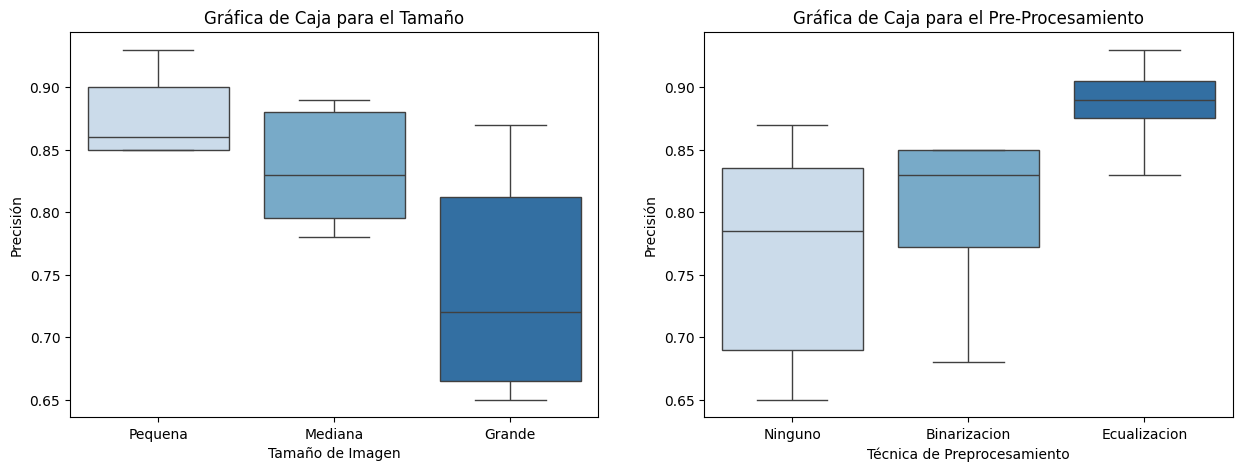

In [5]:
fig, axs = plt.subplots(ncols=2,figsize=(15,5))

sns.boxplot(x='tamanio',y='precision',hue='tamanio',data=df,palette='Blues',orient = 'v',ax=axs[0])
axs[0].set_title('Gráfica de Caja para el Tamaño')
axs[0].set_xlabel("Tamaño de Imagen")
axs[0].set_ylabel("Precisión")

sns.boxplot(x='procesamiento',y='precision',hue='procesamiento',data=df,palette='Blues',orient = 'v',ax=axs[1])
axs[1].set_title('Gráfica de Caja para el Pre-Procesamiento')
axs[1].set_xlabel("Técnica de Preprocesamiento")
axs[1].set_ylabel("Precisión")

In [6]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('precision ~ C(tamanio) + C(procesamiento) + C(tamanio):C(procesamiento)', data=df).fit()
aov_table = sm.stats.anova_lm(model, typ=2)

print(aov_table)

                               sum_sq   df          F    PR(>F)
C(tamanio)                   0.057344  2.0  48.688679  0.000015
C(procesamiento)             0.046044  2.0  39.094340  0.000036
C(tamanio):C(procesamiento)  0.010222  4.0   4.339623  0.031479
Residual                     0.005300  9.0        NaN       NaN


*Interacción ->  C(tamanio):C(procesamiento)*



# Se concluye que el tamaño de la imagen, la técnica de preprocesamiento y su interacción influyen en la precisión del algoritmo


Text(0.5, 0, 'Preprocesamiento')

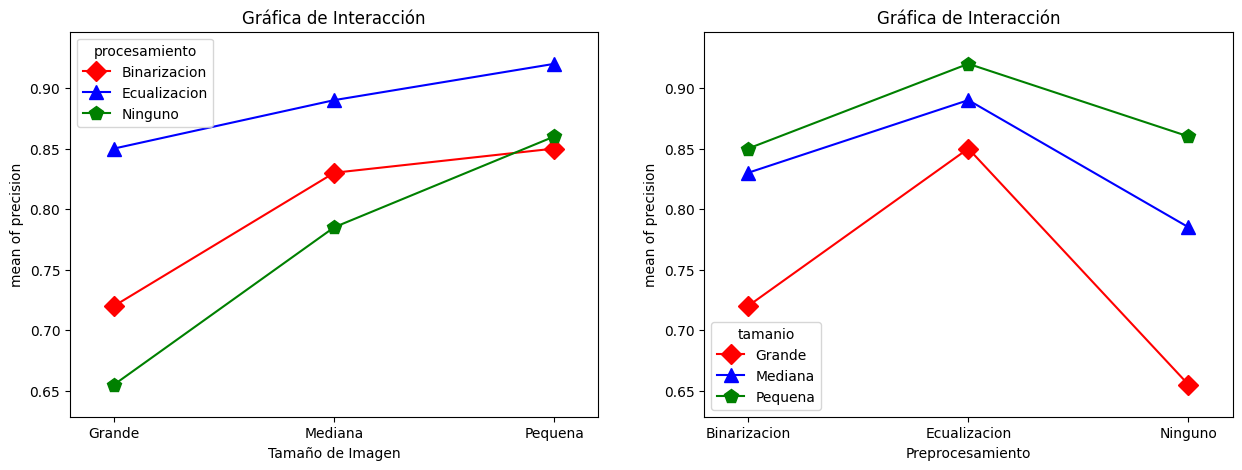

In [7]:
# Visualización de la interacción
from statsmodels.graphics.factorplots import interaction_plot

fig, axs = plt.subplots(ncols=2,figsize=(15,5))

fig = interaction_plot(x=df.tamanio,
    trace=df.procesamiento,
    response=df.precision,
    colors=["red", "blue","green"],
    markers=["D", "^","p"],
    ms=10,ax=axs[0])
axs[0].set_title('Gráfica de Interacción')
axs[0].set_xlabel("Tamaño de Imagen")

fig = interaction_plot(x=df.procesamiento,
    trace=df.tamanio,
    response=df.precision,
    colors=["red", "blue","green"],
    markers=["D", "^","p"],
    ms=10,ax=axs[1])
axs[1].set_title('Gráfica de Interacción')
axs[1].set_xlabel("Preprocesamiento")

Como si influyeron las variables (se cruzan en algún momento) hay que aplicar tukey

In [8]:
import statsmodels.stats.multicomp as mc

tukey = mc.pairwise_tukeyhsd(df.precision, df.tamanio, alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
 Grande Mediana   0.0933 0.0575 -0.0027 0.1894  False
 Grande Pequena    0.135 0.0063  0.0389 0.2311   True
Mediana Pequena   0.0417 0.5132 -0.0544 0.1377  False
-----------------------------------------------------


In [9]:
import statsmodels.stats.multicomp as mc

tukey = mc.pairwise_tukeyhsd(df.precision, df.procesamiento, alpha=0.05)
print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
Binarizacion Ecualizacion   0.0867 0.1124 -0.0179  0.1912  False
Binarizacion      Ninguno  -0.0333 0.6918 -0.1379  0.0712  False
Ecualizacion      Ninguno    -0.12 0.0238 -0.2245 -0.0155   True
----------------------------------------------------------------


Text(0.5, 0.98, 'Verificación de Supuestos del Modelo ANOVA')

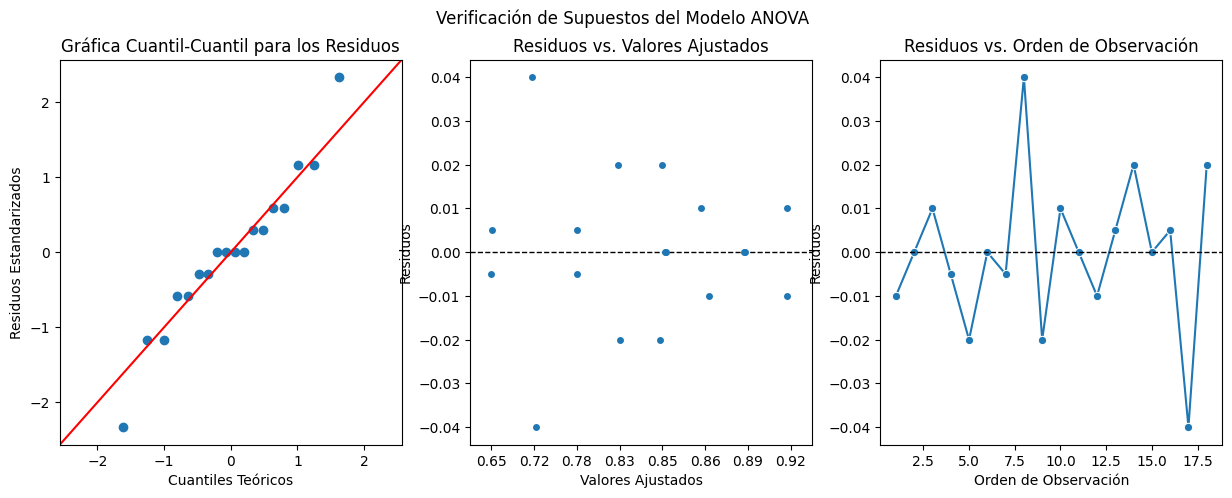

In [10]:
# Verificación de Supuestos

fig, axs = plt.subplots(ncols=3,figsize=(15,5))

res = model.resid
sm.qqplot(res,fit=True ,line='45',ax=axs[0])
axs[0].set_title('Gráfica Cuantil-Cuantil para los Residuos')
axs[0].set_xlabel("Cuantiles Teóricos")
axs[0].set_ylabel("Residuos Estandarizados")



adj = model.fittedvalues.round(2)
sns.stripplot(x=adj,y=res,ax=axs[1])
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[1].set_ylabel('Residuos')
axs[1].set_xlabel('Valores Ajustados')
axs[1].set_title('Residuos vs. Valores Ajustados')


sns.lineplot(x=res.index+1,y=res,marker='o',ax=axs[2])
axs[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[2].set_title('Residuos vs. Orden de Observación')
axs[2].set_xlabel('Orden de Observación')
axs[2].set_ylabel('Residuos')

fig.suptitle('Verificación de Supuestos del Modelo ANOVA')

*Sí cumplen los supestos*